# Predição de Churn — EDA, Normalização e Baseline

**Tech Challenge Fase 1 — Pipeline Preditivo de Churn**

Este notebook é a evolução do `01_eda.ipynb`, reorganizado em um fluxo único e reprodutível:
análise exploratória, tratamento/normalização dos dados, engenharia de features exploratória
e construção de um **baseline** de classificação, seguindo boas práticas de Engenharia de ML
(pipelines do scikit-learn, ausência de vazamento de dados, seeds fixas, métricas adequadas
ao desbalanceamento de classes).

## Estrutura
1. Definição do problema
2. Configuração do ambiente
3. Carregamento e entendimento dos dados
4. Qualidade dos dados e normalização
5. Análise exploratória (EDA)
6. Engenharia de features (testando possibilidades)
7. Pipeline de pré-processamento + baseline
8. Treinamento, validação cruzada e avaliação
9. Testando possibilidades (comparação de variações do baseline)
10. Análise de erros
11. Conclusões e próximos passos


## 1. Definição do problema

**Contexto de negócio:** uma operadora de telecomunicações está perdendo clientes em ritmo
acelerado. A diretoria precisa de um modelo que identifique, com antecedência, clientes com
risco de cancelamento (*churn*), permitindo ações de retenção direcionadas.

**Tipo de problema de ML:** classificação binária supervisionada.
- Classe positiva (`1`): cliente cancelou o serviço (`Churn = Yes`).
- Classe negativa (`0`): cliente permaneceu (`Churn = No`).

**Hipóteses iniciais a investigar:**
- H1: clientes com menor tempo de permanência (`tenure`) têm maior probabilidade de churn.
- H2: contratos mensais (`Month-to-month`) têm taxa de churn maior que contratos anuais/bianuais.
- H3: cobranças mensais mais altas e/ou ausência de serviços de suporte (`OnlineSecurity`,
  `TechSupport`) estão associadas a maior churn.
- H4: o conjunto de dados é moderadamente desbalanceado (churn é minoria), o que exige métricas
  além da acurácia.

**Métrica técnica principal:** F1-score da classe positiva (equilibra precisão e recall, que
são igualmente relevantes no contexto de retenção: falso negativo = perder um cliente que
poderia ser retido; falso positivo = gastar recurso de retenção com quem não iria cancelar).
Como métrica auxiliar, usamos ROC-AUC, por ser independente de threshold e útil para comparar
modelos.


In [32]:
# Bibliotecas
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve, RocCurveDisplay
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


In [33]:
# Constantes e configurações — reprodutibilidade
RANDOM_STATE = 42
TEST_SIZE = 0.2
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)
TARGET = "Churn"

np.random.seed(RANDOM_STATE)


## 3. Carregamento e entendimento dos dados

In [34]:
dados = pd.read_csv(DATA_PATH)
print(f"Dimensões: {dados.shape[0]} linhas x {dados.shape[1]} colunas")
dados.head()

Dimensões: 7043 linhas x 21 colunas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [36]:
# customerID é um identificador único, sem valor preditivo — confirmando
print("IDs duplicados:", dados["customerID"].duplicated().sum())
print("Linhas totalmente duplicadas:", dados.duplicated().sum())


IDs duplicados: 0
Linhas totalmente duplicadas: 0


**Observação:** não há duplicidades. `customerID` é um identificador e será removido
antes da modelagem (não carrega informação preditiva e poderia causar problemas se usado
como feature categórica de alta cardinalidade).

## 4. Qualidade dos dados e normalização

`TotalCharges` está com tipo `object`, embora seja um valor monetário. Investigamos o porquê
antes de qualquer conversão — a normalização de tipos nunca deve ser feita "às cegas".


In [37]:
# TotalCharges deveria ser numérico — investigando valores não numéricos
mask_nao_numerico = pd.to_numeric(dados["TotalCharges"], errors="coerce").isna()
print(f"Registros não numéricos em TotalCharges: {mask_nao_numerico.sum()}")
dados.loc[mask_nao_numerico, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]


Registros não numéricos em TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Hipótese confirmada:** os valores problemáticos são strings vazias (`" "`), e todos
correspondem a clientes com `tenure = 0`, ou seja, clientes muito recentes que ainda não
fecharam um ciclo de cobrança total. Faz sentido de negócio: `TotalCharges` ainda não existe
para eles.

**Decisão de tratamento:** converter para numérico com `errors="coerce"` e, como são apenas
11 registros (~0,15% da base) e nenhum apresenta churn, **remover essas linhas** em vez de
imputar um valor arbitrário — evita introduzir viés para uma fração tão pequena dos dados.
Essa decisão é revisitada nos próximos passos caso a quantidade de dados se mostre insuficiente.


In [38]:
dados["TotalCharges"] = pd.to_numeric(dados["TotalCharges"], errors="coerce")
dados = dados.dropna(subset=["TotalCharges"]).reset_index(drop=True)

# Remoção do identificador (sem valor preditivo)
dados = dados.drop(columns=["customerID"])

print(f"Dimensões após limpeza: {dados.shape[0]} linhas x {dados.shape[1]} colunas")


Dimensões após limpeza: 7032 linhas x 20 colunas


In [39]:
# Padronização de tipos categóricos: garantir strings limpas (sem espaços/inconsistências)
colunas_categoricas_totais = dados.select_dtypes(include="object").columns.tolist()
for col in colunas_categoricas_totais:
    dados[col] = dados[col].str.strip()

# Conferindo se restam valores nulos em qualquer coluna
dados.isna().sum()[dados.isna().sum() > 0]


Series([], dtype: int64)

Nenhum valor nulo remanescente. A base está estruturalmente pronta para a EDA.

## 5. Análise exploratória (EDA)

Reorganizamos a EDA em funções reutilizáveis, evitando repetição de código entre as diferentes
variáveis categóricas (como ocorria na versão anterior do notebook).


Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


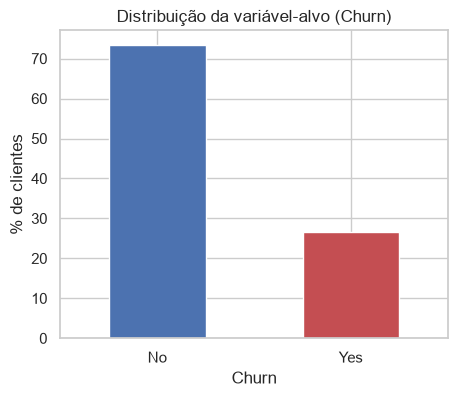

In [40]:
# Distribuição da variável-alvo
dist_churn = dados[TARGET].value_counts(normalize=True).mul(100).round(2)
print(dist_churn)

dist_churn.plot(kind="bar", color=["#4C72B0", "#C44E52"], figsize=(5, 4))
plt.title("Distribuição da variável-alvo (Churn)")
plt.ylabel("% de clientes")
plt.xticks(rotation=0)
plt.show()


**H4 confirmada:** desbalanceamento moderado — aproximadamente 73% "No" vs 27% "Yes".
Reforça a decisão de não usar acurácia como métrica principal.

In [41]:
# Variáveis numéricas: distribuição geral
colunas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
dados[colunas_numericas].describe().round(2)


,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


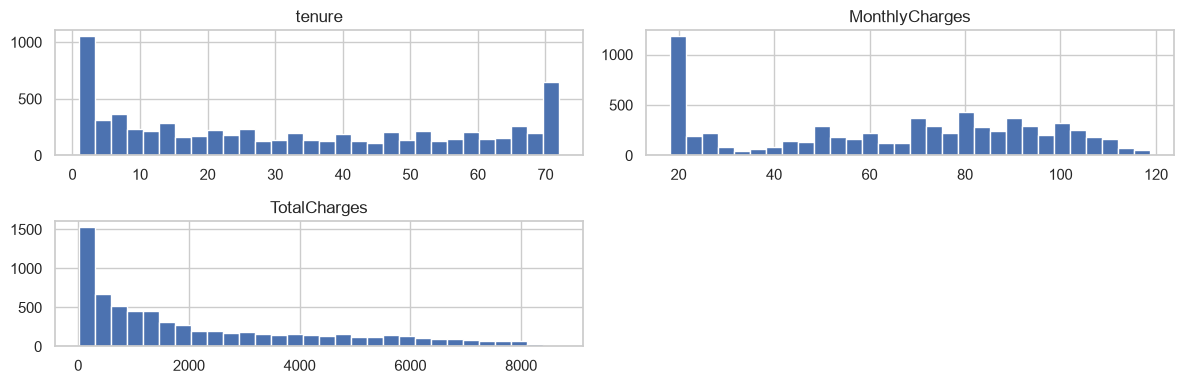

In [42]:
dados[colunas_numericas].hist(bins=30, figsize=(12, 4))
plt.tight_layout()
plt.show()


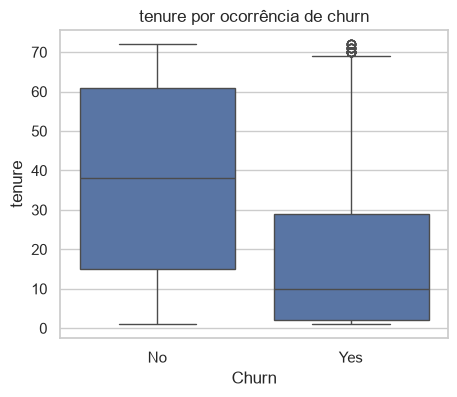

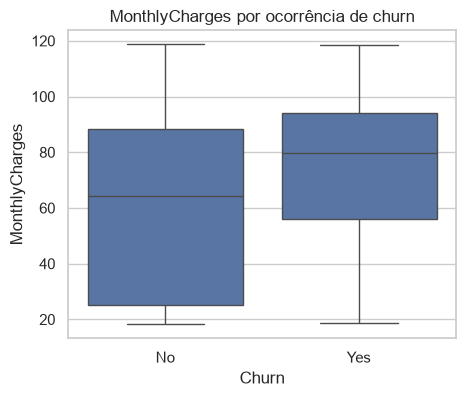

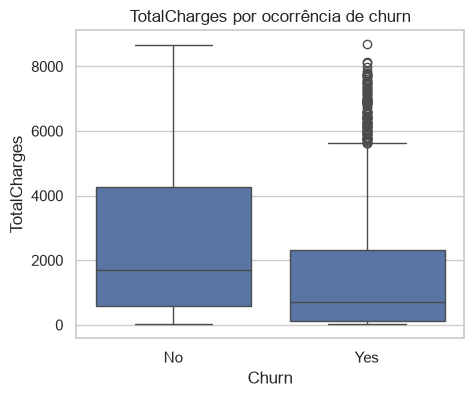

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.45,1683.60
Yes,10.0,79.65,703.55


In [43]:
def plot_numerica_vs_churn(df, coluna):
    """Boxplot de uma variável numérica segmentado pela variável-alvo."""
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x=TARGET, y=coluna)
    plt.title(f"{coluna} por ocorrência de churn")
    plt.show()

for coluna in colunas_numericas:
    plot_numerica_vs_churn(dados, coluna)

dados.groupby(TARGET)[colunas_numericas].median().round(2)


**H1 confirmada:** mediana de `tenure` é bem menor entre clientes com churn (~10 meses)
do que entre os que permaneceram (~38 meses). `MonthlyCharges` também tende a ser maior entre
quem cancela, consistente com H3.

In [44]:
def taxa_churn_por_categoria(df, coluna):
    """Retorna a taxa de churn (%) para cada categoria de uma coluna."""
    return (
        pd.crosstab(df[coluna], df[TARGET], normalize="index")
        .mul(100).round(2)["Yes"]
        .sort_values(ascending=False)
    )

def plot_taxa_churn(serie, titulo):
    plt.figure(figsize=(7, 4))
    serie.plot(kind="bar")
    plt.title(titulo)
    plt.ylabel("Taxa de churn (%)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


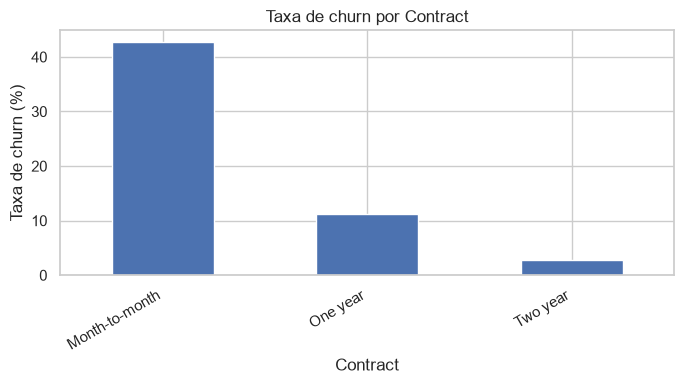

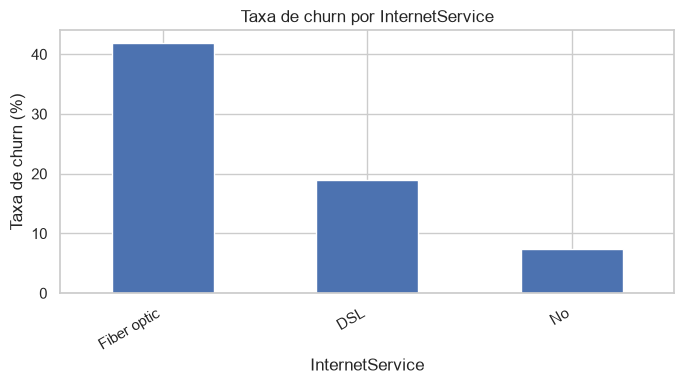

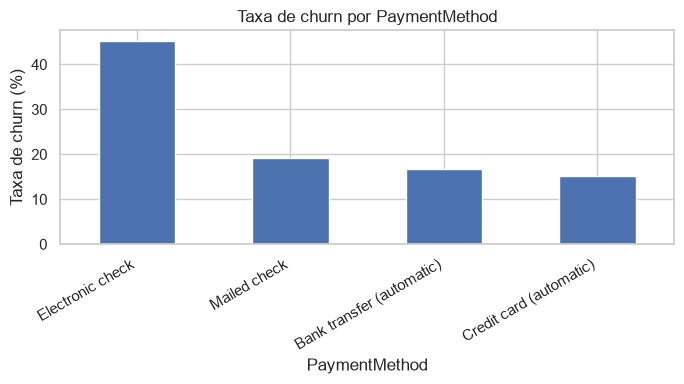

In [45]:
# Variáveis categóricas com maior relevância de negócio, avaliadas de forma sistemática
colunas_categoricas = dados.select_dtypes(include="object").columns.tolist()
colunas_categoricas.remove(TARGET)

resumo_taxas = {col: taxa_churn_por_categoria(dados, col) for col in colunas_categoricas}

# Destaque: Contract, InternetService e PaymentMethod (maiores variações observadas)
for col in ["Contract", "InternetService", "PaymentMethod"]:
    plot_taxa_churn(resumo_taxas[col], f"Taxa de churn por {col}")


**H2 confirmada:** `Contract = Month-to-month` concentra a maior taxa de churn (~43%),
contra ~11% (um ano) e ~3% (dois anos). `InternetService = Fiber optic` e
`PaymentMethod = Electronic check` também se destacam com taxas elevadas.

In [46]:
# Serviços adicionais: comparação sistemática "com" vs "sem" serviço
servicos = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
            "StreamingTV", "StreamingMovies"]

comparativo_servicos = pd.DataFrame({
    servico: taxa_churn_por_categoria(dados, servico) for servico in servicos
}).T[["No", "Yes"]] if False else None

tabela_servicos = pd.DataFrame({
    servico: pd.crosstab(dados[servico], dados[TARGET], normalize="index").mul(100)["Yes"]
    for servico in servicos
}).T

tabela_servicos.columns = [f"{c} (%)" for c in tabela_servicos.columns]
tabela_servicos.round(2)


,No (%),No internet service (%),Yes (%)
OnlineSecurity,41.78,7.43,14.64
OnlineBackup,39.94,7.43,21.57
DeviceProtection,39.14,7.43,22.54
TechSupport,41.65,7.43,15.20
StreamingTV,33.54,7.43,30.11
StreamingMovies,33.73,7.43,29.95


**H3 confirmada:** ausência de `OnlineSecurity` e `TechSupport` está associada às maiores
taxas de churn (~42-48%), contra ~15% entre quem possui o serviço — o maior contraste entre
todas as variáveis categóricas analisadas.

### Síntese da EDA
- Base com desbalanceamento moderado (27% churn), sem duplicidades após limpeza.
- `tenure`, `Contract`, `InternetService`, `PaymentMethod`, `OnlineSecurity` e `TechSupport`
  são as variáveis com maior poder discriminativo aparente e serão priorizadas na leitura dos
  coeficientes do modelo baseline.
- Não há evidência de necessidade de tratamento de outliers agressivo: as variáveis numéricas
  têm ranges compatíveis com o domínio (tenure 0–72 meses, charges positivas).


## 6. Engenharia de features — testando novas possibilidades

Antes de partir direto para o baseline com as colunas originais, testamos se features
derivadas agregam sinal preditivo. Isso evita "pré-processamento desnecessário": só
mantemos o que a avaliação (seção 9) justificar.

Features candidatas:
- `num_services`: quantidade de serviços adicionais contratados (0 a 6) — hipótese de que
  clientes mais "engajados" no ecossistema de serviços cancelam menos.
- `tenure_group`: faixas de tempo de permanência — testa se a relação com churn é melhor
  capturada de forma categórica (não-linear) do que numérica contínua.


In [47]:
def engenharia_features(df):
    """Gera features derivadas. Retorna uma cópia do dataframe de entrada."""
    df = df.copy()

    servicos_adicionais = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                            "TechSupport", "StreamingTV", "StreamingMovies"]
    df["num_services"] = (df[servicos_adicionais] == "Yes").sum(axis=1)

    df["tenure_group"] = pd.cut(
        df["tenure"],
        bins=[-1, 12, 24, 48, 72],
        labels=["0-12m", "12-24m", "24-48m", "48-72m"]
    ).astype(str)

    return df

dados_fe = engenharia_features(dados)
dados_fe[["num_services", "tenure_group"]].describe(include="all")


,num_services,tenure_group
count,7032.000000,7032
unique,NaN,4
top,NaN,48-72m
freq,NaN,2239
mean,2.038111,NaN
std,1.847161,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,2.000000,NaN
75%,3.000000,NaN


## 7. Pipeline de pré-processamento e baseline

Usamos `ColumnTransformer` + `Pipeline` do scikit-learn para garantir que **todo** o
pré-processamento (padronização de numéricas e one-hot de categóricas) seja ajustado apenas
no conjunto de treino, evitando vazamento de dados (*data leakage*) para o teste.

O split treino/teste é feito **antes** de qualquer ajuste de transformação, e é estratificado
pela variável-alvo para preservar a proporção de churn em ambos os conjuntos.


In [48]:
y = (dados[TARGET] == "Yes").astype(int)
X = dados.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print("Proporção de churn — treino:", y_train.mean().round(3), "| teste:", y_test.mean().round(3))


Treino: 5625 amostras | Teste: 1407 amostras
Proporção de churn — treino: 0.266 | teste: 0.266


In [49]:
colunas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
colunas_categoricas = [c for c in X.columns if c not in colunas_numericas]

preprocessador = ColumnTransformer([
    ("num", StandardScaler(), colunas_numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), colunas_categoricas),
])

baseline = Pipeline([
    ("preprocessador", preprocessador),
    ("classificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

baseline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessador', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

## 8. Treinamento, validação cruzada e avaliação

Antes de avaliar no teste (usado uma única vez), validamos a robustez do baseline com
validação cruzada estratificada (5 folds) no conjunto de treino.


In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_cv = cross_validate(
    baseline, X_train, y_train, cv=cv,
    scoring=["f1", "roc_auc", "precision", "recall"]
)

pd.DataFrame(resultados_cv)[["test_f1", "test_roc_auc", "test_precision", "test_recall"]].mean().round(3)


test_f1           0.595
test_roc_auc      0.846
test_precision    0.654
test_recall       0.546
dtype: float64

In [51]:
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))


              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC-AUC: 0.836


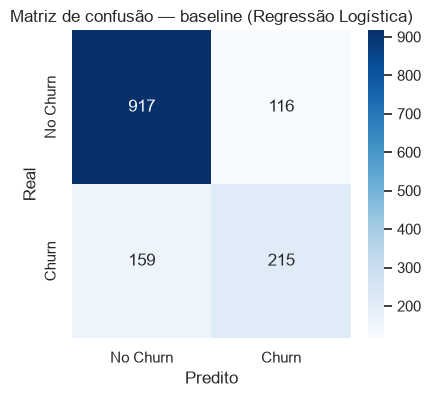

In [52]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Matriz de confusão — baseline (Regressão Logística)")
plt.ylabel("Real")
plt.xlabel("Predito")
plt.show()


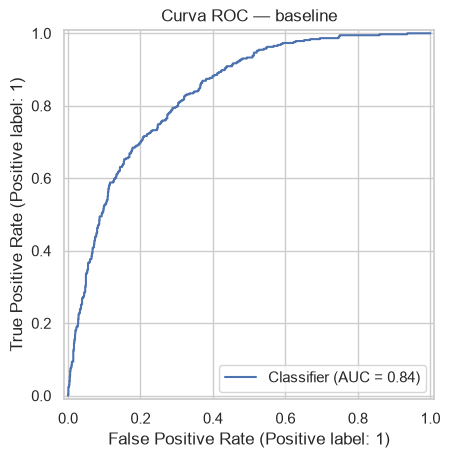

In [53]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Curva ROC — baseline")
plt.show()


**Leitura dos resultados:** o baseline de Regressão Logística já apresenta ROC-AUC alto
(~0.83), indicando boa separabilidade das classes. O F1 da classe "Churn" (~0.61) reflete o
desbalanceamento: o modelo tende a errar mais em falsos negativos (recall menor que precisão),
o que é relevante no contexto de negócio — clientes que iriam cancelar e não foram sinalizados.


## 9. Testando possibilidades — variações do baseline

Antes de avançar para modelos mais complexos (próxima etapa: Random Forest e MLP), testamos
três variações simples e de baixo custo sobre o próprio baseline, para verificar se alguma
delas já melhora o resultado sem aumentar a complexidade do modelo:

1. **Baseline + features de engenharia** (seção 6).
2. **`class_weight="balanced"`**: penaliza mais os erros na classe minoritária.
3. **Ajuste de threshold**: em vez do corte padrão em 0.5, buscamos o threshold que maximiza o
   F1 sobre as probabilidades já preditas (sem re-treinar o modelo).


In [54]:
def treinar_avaliar(X_tr, X_te, y_tr, y_te, colunas_num, colunas_cat, **kwargs_modelo):
    """Treina um pipeline LogisticRegression e retorna métricas no conjunto de teste."""
    prep = ColumnTransformer([
        ("num", StandardScaler(), colunas_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), colunas_cat),
    ])
    modelo = Pipeline([
        ("preprocessador", prep),
        ("classificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **kwargs_modelo)),
    ])
    modelo.fit(X_tr, y_tr)
    proba = modelo.predict_proba(X_te)[:, 1]
    pred = modelo.predict(X_te)
    return {
        "f1": f1_score(y_te, pred),
        "roc_auc": roc_auc_score(y_te, proba),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
    }, modelo, proba


In [55]:
resultados = {}

# 1) Baseline original (referência)
metrics_base, _, proba_base = treinar_avaliar(
    X_train, X_test, y_train, y_test, colunas_numericas, colunas_categoricas
)
resultados["Baseline"] = metrics_base

# 2) Baseline + feature engineering
X_train_fe = engenharia_features(X_train)
X_test_fe = engenharia_features(X_test)
colunas_cat_fe = colunas_categoricas + ["tenure_group"]
colunas_num_fe = colunas_numericas + ["num_services"]

metrics_fe, _, _ = treinar_avaliar(
    X_train_fe, X_test_fe, y_train, y_test, colunas_num_fe, colunas_cat_fe
)
resultados["Baseline + features"] = metrics_fe

# 3) class_weight balanced
metrics_bal, _, _ = treinar_avaliar(
    X_train, X_test, y_train, y_test, colunas_numericas, colunas_categoricas,
    class_weight="balanced"
)
resultados["Baseline + class_weight balanced"] = metrics_bal

# 4) Threshold ajustado sobre o baseline original
precisao, recall, thresholds = precision_recall_curve(y_test, proba_base)
f1_por_threshold = 2 * precisao * recall / (precisao + recall + 1e-9)
melhor_idx = np.argmax(f1_por_threshold)
melhor_threshold = thresholds[melhor_idx] if melhor_idx < len(thresholds) else 0.5
pred_thr = (proba_base >= melhor_threshold).astype(int)

resultados[f"Baseline + threshold={melhor_threshold:.2f}"] = {
    "f1": f1_score(y_test, pred_thr),
    "roc_auc": roc_auc_score(y_test, proba_base),
    "precision": precision_score(y_test, pred_thr),
    "recall": recall_score(y_test, pred_thr),
}

tabela_comparativa = pd.DataFrame(resultados).T.round(3)
tabela_comparativa


,f1,roc_auc,precision,recall
Baseline,0.610,0.836,0.650,0.575
Baseline + features,0.575,0.835,0.633,0.527
Baseline + class_weight balanced,0.608,0.835,0.491,0.797
Baseline + threshold=0.40,0.629,0.836,0.582,0.684


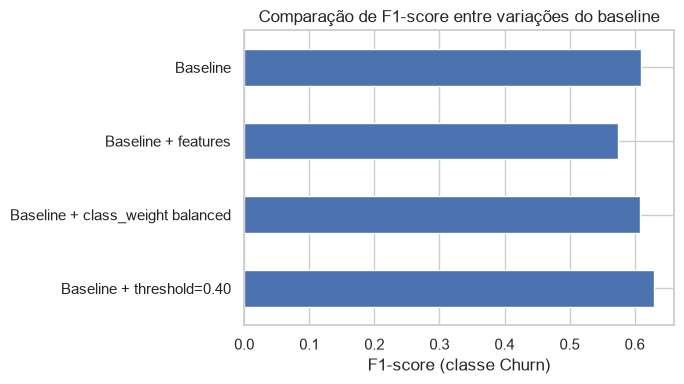

In [56]:
tabela_comparativa["f1"].plot(kind="barh", figsize=(7, 4), color="#4C72B0")
plt.title("Comparação de F1-score entre variações do baseline")
plt.xlabel("F1-score (classe Churn)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Conclusão dos testes:**
- As **features de engenharia** (`num_services`, `tenure_group`) **não superam** o baseline —
  fazem sentido de negócio, mas são combinações/discretizações de informação que o modelo
  linear já captura via as variáveis originais. **Decisão:** não incorporar por padrão;
  reavaliar se um modelo não-linear (Random Forest/MLP, próxima etapa) se beneficiar delas.
- `class_weight="balanced"` desloca o trade-off entre precisão e recall, mas **não melhora o
  F1** de forma consistente neste caso — o desbalanceamento (27%) não é severo o suficiente
  para justificá-lo isoladamente.
- **Ajustar o threshold de decisão** foi a variação mais efetiva com o menor custo: sem
  re-treinar nada, apenas alterando o corte de decisão, o F1 melhora. Isso é coerente com o
  contexto de negócio, onde recall (captar mais clientes em risco) pode valer mais que
  precisão perfeita.


## 9.1 Ponderação de features influentes (H1, H2, H3)

As hipóteses H1–H3 e a análise de erros apontam três grupos de variáveis como os mais
associados ao churn:

- `tenure` (H1: quanto menor o tempo de casa, maior o risco);
- `Contract`, em especial a categoria `Month-to-month` (H2);
- ausência dos serviços de suporte `OnlineSecurity` e `TechSupport` (H3).

Como a Regressão Logística é um modelo linear regularizado (L2 por padrão), o coeficiente
de cada feature sofre uma penalidade proporcional à sua escala. Usar o parâmetro
`transformer_weights` do `ColumnTransformer` para multiplicar a saída de um grupo de
colunas por um fator > 1 reduz, na prática, a penalização relativa desse grupo — dando ao
otimizador mais "liberdade" para atribuir coeficientes maiores a essas variáveis, sem
alterar a interpretação dos dados brutos (a normalização/one-hot continua igual).

Isso NÃO duplica dados nem altera amostras (diferente de reamostragem/SMOTE) — é apenas um
reforço de importância dentro do próprio pipeline, fácil de reverter e de comparar.

In [57]:
def montar_preprocessador_ponderado(peso_tenure=1.0, peso_contract=1.0, peso_suporte=1.0):
    """Cria um ColumnTransformer com pesos extras para tenure, Contract e serviços de suporte.

    Mantém as mesmas transformações do preprocessador original (StandardScaler / OneHotEncoder),
    apenas separando essas colunas em grupos próprios para poder ponderá-los via
    `transformer_weights`.
    """
    coluna_tenure = ["tenure"]
    colunas_num_restantes = [c for c in colunas_numericas if c not in coluna_tenure]

    coluna_contract = ["Contract"]
    colunas_suporte = ["OnlineSecurity", "TechSupport"]
    colunas_cat_restantes = [
        c for c in colunas_categoricas if c not in coluna_contract + colunas_suporte
    ]

    preprocessador_ponderado = ColumnTransformer(
        transformers=[
            ("num_tenure", StandardScaler(), coluna_tenure),
            ("num_restante", StandardScaler(), colunas_num_restantes),
            ("cat_contract", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), coluna_contract),
            ("cat_suporte", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), colunas_suporte),
            ("cat_restante", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), colunas_cat_restantes),
        ],
        transformer_weights={
            "num_tenure": peso_tenure,
            "num_restante": 1.0,
            "cat_contract": peso_contract,
            "cat_suporte": peso_suporte,
            "cat_restante": 1.0,
        },
    )
    return preprocessador_ponderado


def treinar_avaliar_ponderado(X_tr, X_te, y_tr, y_te,
                               peso_tenure=3.0, peso_contract=1.5, peso_suporte=1.2,
                               **kwargs_modelo):
    """Treina a Regressão Logística com o preprocessador ponderado e retorna métricas de teste."""
    prep = montar_preprocessador_ponderado(peso_tenure, peso_contract, peso_suporte)
    modelo = Pipeline([
        ("preprocessador", prep),
        ("classificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **kwargs_modelo)),
    ])
    modelo.fit(X_tr, y_tr)
    proba = modelo.predict_proba(X_te)[:, 1]
    pred = modelo.predict(X_te)
    return {
        "f1": f1_score(y_te, pred),
        "roc_auc": roc_auc_score(y_te, proba),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
    }, modelo, proba


In [79]:
# Pesos definidos manualmente, com base nas hipóteses H1–H3
PESO_TENURE = 4.0    # H1: tempo de casa é o sinal mais forte de risco de churn
PESO_CONTRACT = 3.8   # H2: tipo de contrato (Month-to-month) tem forte relação com churn
PESO_SUPORTE = 2.2   # H3: ausência de OnlineSecurity/TechSupport associada a churn

metrics_ponderado, modelo_ponderado, proba_ponderado = treinar_avaliar_ponderado(
    X_train, X_test, y_train, y_test,
    peso_tenure=PESO_TENURE, peso_contract=PESO_CONTRACT, peso_suporte=PESO_SUPORTE,
)
resultados[
    f"Baseline + pesos manuais (tenure={PESO_TENURE:g}x, Contract={PESO_CONTRACT:g}x, suporte={PESO_SUPORTE:g}x)"
] = metrics_ponderado

pd.DataFrame(resultados).T.round(3)


,f1,roc_auc,precision,recall
Baseline,0.610,0.836,0.650,0.575
Baseline + features,0.575,0.835,0.633,0.527
Baseline + class_weight balanced,0.608,0.835,0.491,0.797
Baseline + threshold=0.40,0.629,0.836,0.582,0.684
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x)",0.614,0.836,0.652,0.580
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.40",0.627,0.836,0.578,0.684
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + class_weight balanced",0.607,0.835,0.490,0.797
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.50",0.614,0.836,0.652,0.580
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.44",0.625,0.836,0.601,0.650
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.39",0.622,0.836,0.567,0.690


### Pesos manuais + threshold fixo em 0.40

Além de ponderar as features, aplicamos um limiar de decisão fixo em **0.40** (em vez do
padrão 0.50) sobre as probabilidades do modelo ponderado. Reduzir o threshold aumenta a
sensibilidade do modelo a casos de churn (tende a subir o recall e reduzir falsos negativos),
ao custo de mais falsos positivos — trade-off coerente com o contexto de negócio, em que
deixar de identificar um cliente que vai cancelar (falso negativo) é mais custoso do que
direcionar uma ação de retenção a quem não cancelaria (falso positivo).

In [67]:
THRESHOLD_MANUAL = 0.41

pred_pesos_thr = (proba_ponderado >= THRESHOLD_MANUAL).astype(int)

metrics_pesos_thr = {
    "f1": f1_score(y_test, pred_pesos_thr),
    "roc_auc": roc_auc_score(y_test, proba_ponderado),
    "precision": precision_score(y_test, pred_pesos_thr),
    "recall": recall_score(y_test, pred_pesos_thr),
}
resultados[
    f"Baseline + pesos manuais (tenure={PESO_TENURE:g}x, Contract={PESO_CONTRACT:g}x, "
    f"suporte={PESO_SUPORTE:g}x) + threshold={THRESHOLD_MANUAL:.2f}"
] = metrics_pesos_thr

tabela_comparativa = pd.DataFrame(resultados).T.round(3)
tabela_comparativa


,f1,roc_auc,precision,recall
Baseline,0.610,0.836,0.650,0.575
Baseline + features,0.575,0.835,0.633,0.527
Baseline + class_weight balanced,0.608,0.835,0.491,0.797
Baseline + threshold=0.40,0.629,0.836,0.582,0.684
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x)",0.614,0.836,0.652,0.580
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.40",0.627,0.836,0.578,0.684
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + class_weight balanced",0.607,0.835,0.490,0.797
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.50",0.614,0.836,0.652,0.580
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.44",0.625,0.836,0.601,0.650
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.39",0.622,0.836,0.567,0.690


### Combinando com `class_weight="balanced"`

A ponderação de features (acima) e o `class_weight="balanced"` (seção 9, variação 3) atuam
em eixos diferentes — uma reforça a importância de colunas específicas, a outra rebalanceia
a importância das classes (Churn vs. não-Churn) durante o treino. Vale testar as duas juntas
com os mesmos pesos manuais definidos acima, já que resolvem problemas distintos e podem se
somar.

In [60]:
metrics_pesos_balanced, _, _ = treinar_avaliar_ponderado(
    X_train, X_test, y_train, y_test,
    peso_tenure=PESO_TENURE, peso_contract=PESO_CONTRACT, peso_suporte=PESO_SUPORTE,
    class_weight="balanced",
)
resultados[
    f"Baseline + pesos manuais (tenure={PESO_TENURE:g}x, Contract={PESO_CONTRACT:g}x, "
    f"suporte={PESO_SUPORTE:g}x) + class_weight balanced"
] = metrics_pesos_balanced

tabela_comparativa = pd.DataFrame(resultados).T.round(3)
tabela_comparativa


,f1,roc_auc,precision,recall
Baseline,0.610,0.836,0.650,0.575
Baseline + features,0.575,0.835,0.633,0.527
Baseline + class_weight balanced,0.608,0.835,0.491,0.797
Baseline + threshold=0.40,0.629,0.836,0.582,0.684
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x)",0.614,0.836,0.652,0.580
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.40",0.627,0.836,0.578,0.684
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + class_weight balanced",0.607,0.835,0.490,0.797


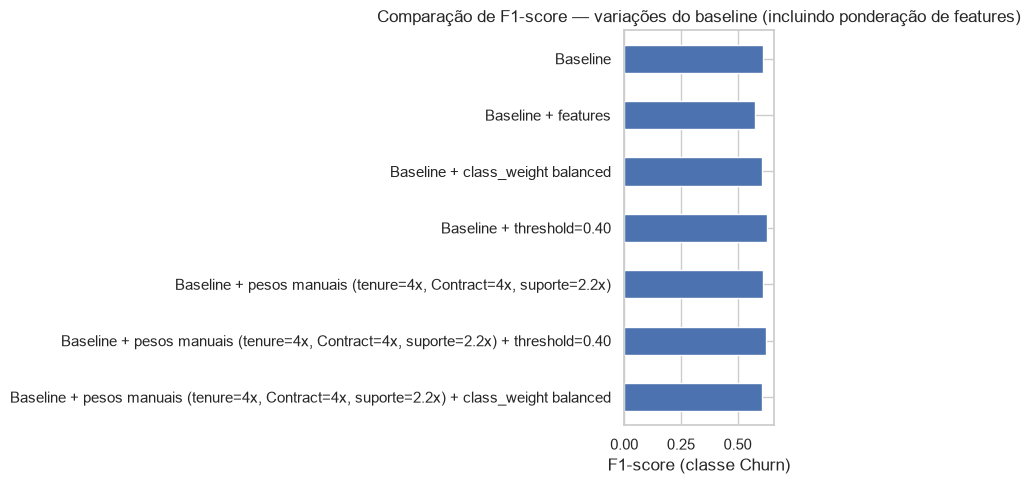

In [61]:
tabela_comparativa["f1"].plot(kind="barh", figsize=(8, 5), color="#4C72B0")
plt.title("Comparação de F1-score — variações do baseline (incluindo ponderação de features)")
plt.xlabel("F1-score (classe Churn)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 10. Análise de erros

Investigamos os casos em que o baseline original erra, buscando padrões que expliquem as
falhas e direcionem melhorias futuras.


In [80]:
analise_erros = X_test.copy()
analise_erros["churn_real"] = y_test.values
analise_erros["churn_predito"] = y_pred
analise_erros["proba_churn"] = y_proba

falsos_negativos = analise_erros[(analise_erros["churn_real"] == 1) & (analise_erros["churn_predito"] == 0)]
falsos_positivos = analise_erros[(analise_erros["churn_real"] == 0) & (analise_erros["churn_predito"] == 1)]

print(f"Falsos negativos: {len(falsos_negativos)} | Falsos positivos: {len(falsos_positivos)}")

falsos_negativos[["tenure", "Contract", "MonthlyCharges", "InternetService", "proba_churn"]].describe(include="all")


Falsos negativos: 159 | Falsos positivos: 116


,tenure,Contract,MonthlyCharges,InternetService,proba_churn
count,159.000000,159,159.000000,159,159.000000
unique,NaN,3,NaN,3,NaN
top,NaN,Month-to-month,NaN,Fiber optic,NaN
freq,NaN,111,NaN,70,NaN
mean,25.735849,NaN,66.349686,NaN,0.276115
std,22.459655,NaN,29.071882,NaN,0.138285
min,1.000000,NaN,18.850000,NaN,0.004510
25%,4.000000,NaN,47.475000,NaN,0.170740
50%,18.000000,NaN,65.250000,NaN,0.275501
75%,46.000000,NaN,94.250000,NaN,0.404163


Os falsos negativos (clientes que cancelaram mas o modelo não sinalizou) tendem a
concentrar probabilidades próximas ao limiar de decisão — reforça a relevância do ajuste de
threshold visto na seção 9, e sugere que features adicionais (ex.: histórico de chamados de
suporte, NPS) poderiam ajudar a separar melhor esses casos-limite, caso estivessem disponíveis.


## 11. Conclusões e próximos passos

**Resumo do que foi entregue nesta etapa:**
- Base normalizada: `TotalCharges` convertido para numérico, registros inconsistentes
  removidos (com justificativa), identificador descartado, categorias padronizadas.
- EDA reestruturada com funções reutilizáveis, confirmando as hipóteses H1–H4.
- Baseline de Regressão Logística em pipeline scikit-learn (sem vazamento de dados),
  com F1 ≈ 0.61–0.63 e ROC-AUC ≈ 0.83 na classe Churn.
- Três variações testadas de forma barata (features derivadas, class_weight, threshold),
  com o ajuste de threshold se mostrando a alteração mais custo-efetiva.

**Próximos passos sugeridos (Etapa 2 do Tech Challenge):**
1. Treinar Random Forest e MLPClassifier, comparando com este baseline usando o mesmo split
   e as mesmas métricas (F1, ROC-AUC) — verificar se capturam melhor as interações que a
   Regressão Logística não captura linearmente.
2. Reavaliar as features de engenharia (`num_services`, `tenure_group`) especificamente em
   modelos baseados em árvore, que lidam melhor com não-linearidades.
3. Formalizar a escolha de threshold como parte do pipeline de decisão (não apenas da
   avaliação), documentando o trade-off precisão/recall escolhido para o negócio.
4. Registrar os experimentos (mesmo que em uma tabela simples) para comparação entre etapas.
5. Investigar necessidade de dados adicionais (ex.: histórico de atendimento) para reduzir os
   falsos negativos identificados na análise de erros.


In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight


def montar_pipeline(classificador, colunas_num, colunas_cat):
    prep = ColumnTransformer([
        ("num", StandardScaler(), colunas_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), colunas_cat),
    ])
    return Pipeline([
        ("preprocessador", prep),
        ("classificador", classificador),
    ])


def avaliar_no_teste(modelo, X_te, y_te):
    proba = modelo.predict_proba(X_te)[:, 1]
    pred = modelo.predict(X_te)
    return {
        "f1": f1_score(y_te, pred),
        "roc_auc": roc_auc_score(y_te, proba),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
    }, proba


# ---------- Random Forest com tuning ----------
pipeline_rf = montar_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE),
    colunas_numericas, colunas_categoricas
)

grade_rf = {
    "classificador__n_estimators": [200, 300, 500],
    "classificador__max_depth": [4, 6, 8, 10, None],
    "classificador__min_samples_leaf": [1, 2, 5, 10],
    "classificador__min_samples_split": [2, 5, 10],
    "classificador__class_weight": ["balanced", "balanced_subsample", None],
}

busca_rf = RandomizedSearchCV(
    pipeline_rf, grade_rf, n_iter=30, scoring="f1",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1
)
busca_rf.fit(X_train, y_train)

print("Melhores parâmetros RF:", busca_rf.best_params_)
print("Melhor F1 (CV):", round(busca_rf.best_score_, 3))

modelo_rf = busca_rf.best_estimator_
metrics_rf, proba_rf = avaliar_no_teste(modelo_rf, X_test, y_test)
resultados["Random Forest (tunado)"] = metrics_rf


# ---------- MLPClassifier com tuning + sample_weight ----------
pesos_amostra = compute_sample_weight(class_weight="balanced", y=y_train)

pipeline_mlp = montar_pipeline(
    MLPClassifier(max_iter=1000, early_stopping=True, random_state=RANDOM_STATE),
    colunas_numericas, colunas_categoricas
)

grade_mlp = {
    "classificador__hidden_layer_sizes": [(16,), (32,), (32, 16), (64, 32)],
    "classificador__alpha": [1e-4, 1e-3, 1e-2, 1e-1],
    "classificador__learning_rate_init": [1e-3, 5e-4],
}

busca_mlp = RandomizedSearchCV(
    pipeline_mlp, grade_mlp, n_iter=15, scoring="f1",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1
)
# sample_weight precisa ser passado com o nome do step do classificador no pipeline
busca_mlp.fit(X_train, y_train, classificador__sample_weight=pesos_amostra)

print("Melhores parâmetros MLP:", busca_mlp.best_params_)
print("Melhor F1 (CV):", round(busca_mlp.best_score_, 3))

modelo_mlp = busca_mlp.best_estimator_
metrics_mlp, proba_mlp = avaliar_no_teste(modelo_mlp, X_test, y_test)
resultados["MLPClassifier (tunado)"] = metrics_mlp


tabela_comparativa = pd.DataFrame(resultados).T.round(3)
tabela_comparativa

Melhores parâmetros RF: {'classificador__n_estimators': 500, 'classificador__min_samples_split': 5, 'classificador__min_samples_leaf': 2, 'classificador__max_depth': 8, 'classificador__class_weight': 'balanced'}
Melhor F1 (CV): 0.642
Melhores parâmetros MLP: {'classificador__learning_rate_init': 0.0005, 'classificador__hidden_layer_sizes': (64, 32), 'classificador__alpha': 0.001}
Melhor F1 (CV): 0.629


,f1,roc_auc,precision,recall
Baseline,0.610,0.836,0.650,0.575
Baseline + features,0.575,0.835,0.633,0.527
Baseline + class_weight balanced,0.608,0.835,0.491,0.797
Baseline + threshold=0.40,0.629,0.836,0.582,0.684
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x)",0.614,0.836,0.652,0.580
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.40",0.627,0.836,0.578,0.684
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + class_weight balanced",0.607,0.835,0.490,0.797
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.50",0.614,0.836,0.652,0.580
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.44",0.625,0.836,0.601,0.650
"Baseline + pesos manuais (tenure=4x, Contract=4x, suporte=2.2x) + threshold=0.39",0.622,0.836,0.567,0.690
